# 🏦 Credit Risk Classification
### Using Machine Learning to Predict Credit Risk on the German Credit Dataset

**Models Covered:**
- Logistic Regression
- K-Nearest Neighbours (KNN)
- Artificial Neural Network (ANN via Keras)

---

## 📦 Step 1: Import Libraries

We import all the tools we need:
- **pandas / numpy** — data manipulation
- **matplotlib / seaborn** — visualizations
- **sklearn** — ML models, preprocessing, and evaluation
- **keras** — building the Artificial Neural Network

In [1]:
import keras
import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 📂 Step 2: Load the Dataset

We use the **German Credit dataset** from OpenML (`credit-g`).

- **1,000 rows** — each row is a loan applicant
- **20 features** — age, credit amount, duration, employment, etc.
- **Target column (`class`)** — either `good` or `bad` credit risk

> 🗣️ *"This is a classic binary classification dataset widely used in the finance and ML community."*

In [2]:
# Load the German Credit dataset from OpenML
dataset = fetch_openml("credit-g")
df = dataset.frame

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (1000, 21)
Columns: ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'class']


/opt/anaconda3/lib/python3.10/site-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name credit-g exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=31
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=44096

  warn(warning_msg)


In [3]:
# Preview the first few rows
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [4]:
# Statistical summary of numerical columns
df.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


---
## 📊 Step 3: Exploratory Data Analysis (EDA)

Before building any model, we visualize the data to:
- Understand the **class distribution** (is the dataset balanced?)
- Find **correlations** between features
- Spot **trends** between features and the target

> 🗣️ *"EDA helps us understand what we're working with before we train any model."*

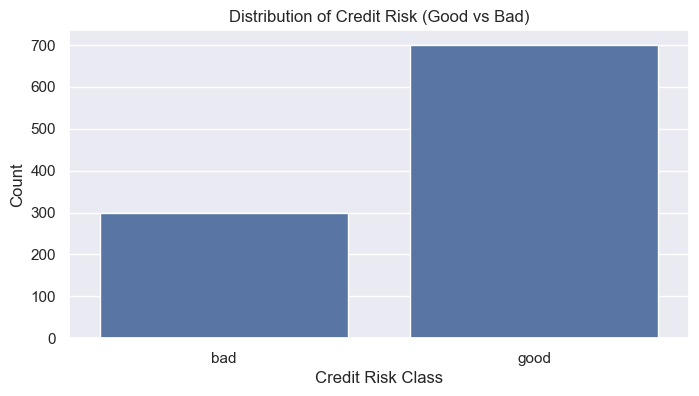

class
good    700
bad     300
Name: count, dtype: int64


In [5]:
# --- Plot 1: Class Distribution Bar Chart ---
# Are there roughly equal numbers of 'good' and 'bad' credit applicants?

plt.figure(figsize=(8, 4))
sn.set(style="darkgrid")
sn.countplot(x="class", data=df)
plt.title('Distribution of Credit Risk (Good vs Bad)')
plt.xlabel('Credit Risk Class')
plt.ylabel('Count')
plt.show()

print(df['class'].value_counts())

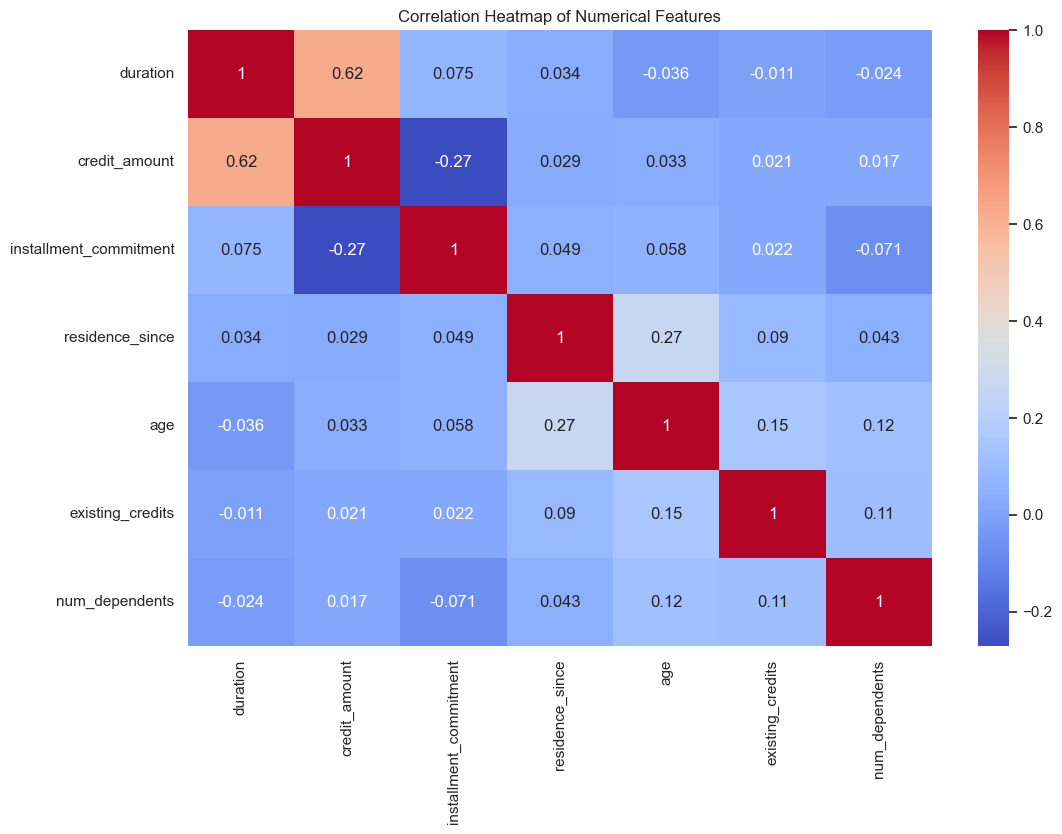

In [6]:
# --- Plot 2: Correlation Heatmap ---
# Which numerical features are strongly correlated with each other?
# High correlation between two input features can cause problems (multicollinearity)

plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sn.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

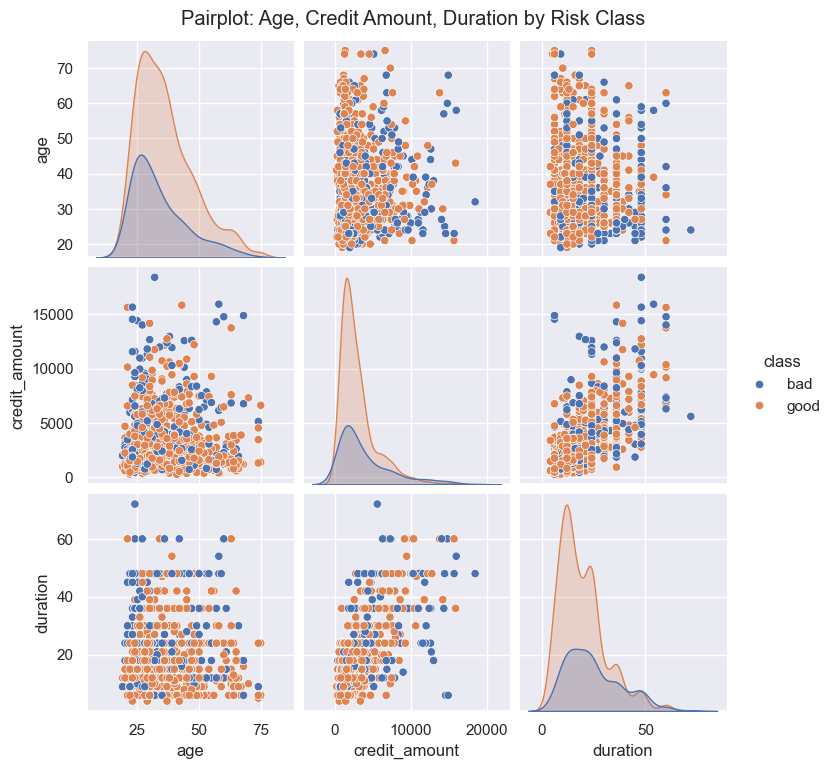

In [7]:
# --- Plot 3: Pairplot ---
# How do age, credit amount, and duration relate to each other, split by risk class?

sn.pairplot(data=df, vars=['age', 'credit_amount', 'duration'], hue="class")
plt.suptitle('Pairplot: Age, Credit Amount, Duration by Risk Class', y=1.02)
plt.show()

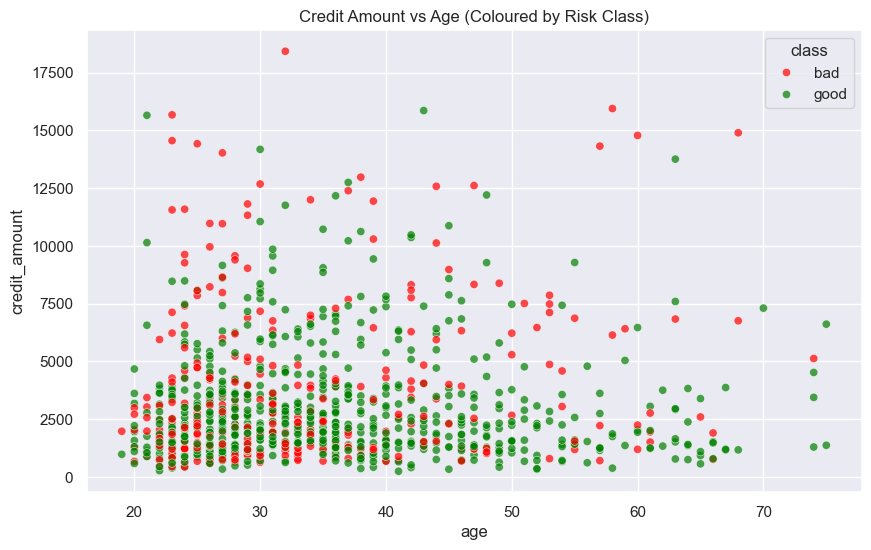

In [8]:
# --- Plot 4: Scatter Plot — Age vs Credit Amount ---
# Do older applicants take out larger loans? Does that affect their credit risk?

plt.figure(figsize=(10, 6))
sn.scatterplot(
    data=df, x="age", y="credit_amount",
    hue="class", palette={'good': 'green', 'bad': 'red'}, alpha=0.7
)
plt.title('Credit Amount vs Age (Coloured by Risk Class)')
plt.show()

/var/folders/th/q8sxrmb5083cbcg_zdrxmb300000gn/T/ipykernel_42405/594682704.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


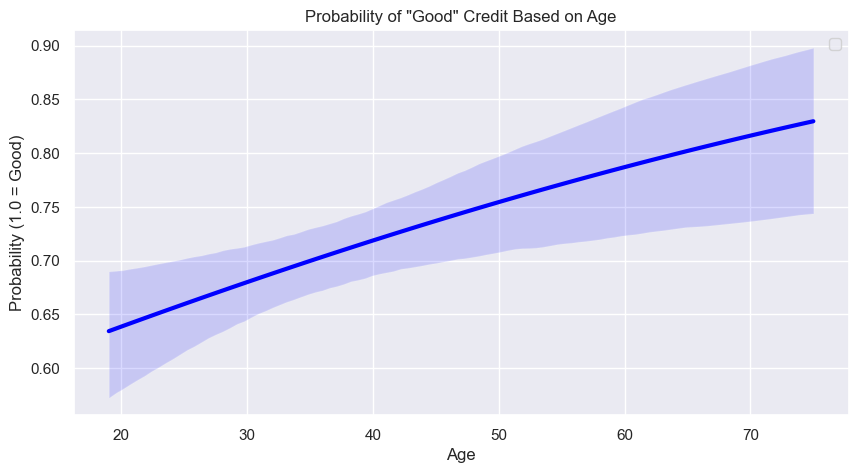

In [9]:
# --- Plot 5: Logistic Regression Curve (Age vs Probability of Good Credit) ---
# This previews the idea behind logistic regression:
# it models the PROBABILITY of an outcome (not a straight line)

# Create a numeric target for plotting only
df['target_num'] = df['class'].str.strip("'").map({'good': 1, 'bad': 0})

plt.figure(figsize=(10, 5))
sn.regplot(
    x='age', y='target_num', data=df,
    logistic=True, scatter=False,
    line_kws={'color': 'blue', 'linewidth': 3, 'label': 'Probability of Good Credit'}
)
plt.title('Probability of "Good" Credit Based on Age')
plt.ylabel('Probability (1.0 = Good)')
plt.xlabel('Age')
plt.legend()
plt.show()

---
## 🧹 Step 4: Check for Missing Values

Real-world data is messy. Before training, we must confirm:
- Are there **null / NaN values**?
- If so, we'd need to drop or impute them

> 🗣️ *"Missing values can cause models to crash or produce inaccurate results."*

In [10]:
# Count missing values per column
missing_counts = df.isna().sum()
print("Missing values per column:")
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "✅ No missing values found!")

# Data types overview
df.info()

Missing values per column:
✅ No missing values found!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1

---
## ⚙️ Step 5: Data Preprocessing

Machine learning models require **numbers**, not text. We need to:

1. **Separate X (features) and y (target)**
2. **Label Encode** the target column (`good` → 1, `bad` → 0)
3. **One-Hot Encode** categorical feature columns (turns text into 0/1 columns)
4. **Standardize / Scale** the features so no single feature dominates

> 🗣️ *"Standardization ensures features like 'age' (range: 18–75) and 'credit_amount' (range: 250–18,000) are treated equally by the model."*

In [11]:
# --- Separate X (input features) and y (target label) ---
X = df.iloc[:, 0:20]   # First 20 columns are features
y = df.iloc[:, 20]     # Column 21 is the class label

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget value counts:\n{y.value_counts()}")

X shape: (1000, 20)
y shape: (1000,)

Target value counts:
class
good    700
bad     300
Name: count, dtype: int64


In [12]:
# --- Label Encode the Target Column ---
# 'bad'  → 0
# 'good' → 1

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Original y (first 10):", list(y[:10]))
print("Encoded  y (first 10):", y_encoded[:10])
print(f"\nClasses: {le.classes_}  →  Encoded as: {le.transform(le.classes_)}")

Original y (first 10): ['good', 'bad', 'good', 'good', 'bad', 'good', 'good', 'good', 'good', 'bad']
Encoded  y (first 10): [1 0 1 1 0 1 1 1 1 0]

Classes: ['bad' 'good']  →  Encoded as: [0 1]


In [13]:
# --- One-Hot Encode Categorical Feature Columns ---
# Converts text columns (like 'checking_status', 'housing') into binary 0/1 columns
# drop_first=True avoids the dummy variable trap (removes one redundant column per category)

X_encoded = pd.get_dummies(X, drop_first=True).astype(int)

print(f"Shape before encoding: {X.shape}")
print(f"Shape after encoding:  {X_encoded.shape}")
X_encoded.head()

Shape before encoding: (1000, 20)
Shape after encoding:  (1000, 48)


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status_<0,checking_status_>=200,checking_status_no checking,...,property_magnitude_car,other_payment_plans_none,other_payment_plans_stores,housing_own,housing_rent,job_unemp/unskilled non res,job_unskilled resident,job_skilled,own_telephone_yes,foreign_worker_yes
0,6,1169,4,4,67,2,1,1,0,0,...,0,1,0,1,0,0,0,1,1,1
1,48,5951,2,2,22,1,1,0,0,0,...,0,1,0,1,0,0,0,1,0,1
2,12,2096,2,3,49,1,2,0,0,1,...,0,1,0,1,0,0,1,0,0,1
3,42,7882,2,4,45,1,2,1,0,0,...,0,1,0,0,0,0,0,1,0,1
4,24,4870,3,4,53,2,2,1,0,0,...,0,1,0,0,0,0,0,1,0,1


In [14]:
# --- Standardize / Scale the Features ---
# StandardScaler transforms each feature to have mean=0 and std=1
# This is especially important for KNN and ANN

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Original first row (sample):", X_encoded.iloc[0].values[:5], "...")
print("Scaled   first row (sample):", X_scaled[0][:5].round(3), "...")

Original first row (sample): [   6 1169    4    4   67] ...
Scaled   first row (sample): [-1.236 -0.745  0.918  1.047  2.766] ...


---
## ✂️ Step 6: Train / Test Split

We split data into:
- **75% Training set** — used to teach the model
- **25% Testing set** — used to evaluate how well it generalises to unseen data

> 🗣️ *"We never let the model see the test set during training — it acts as our 'exam' at the end."*

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.25,
    random_state=0,
    shuffle=True
)

print(f"Training samples:  {len(X_train)}")
print(f"Testing  samples:  {len(X_test)}")

Training samples:  750
Testing  samples:  250


---
## 🔵 Model 1: Logistic Regression

**What is it?**  
Logistic Regression is a **parametric model** — it finds the best set of weights (coefficients) to model the probability of an outcome.

- Uses the **sigmoid function** to output a probability between 0 and 1
- Simple, fast, and highly interpretable
- Good **baseline** to compare against more complex models

> 🗣️ *"Think of it as fitting a curve (not a line) to separate 'good' from 'bad' credit applicants."*

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Train
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Predict
lr_predictions = lr_model.predict(X_test)

# Accuracy
print(f"Training Accuracy: {lr_model.score(X_train, y_train):.4f}")
print(f"Testing  Accuracy: {lr_model.score(X_test,  y_test):.4f}")

Training Accuracy: 0.7947
Testing  Accuracy: 0.7360


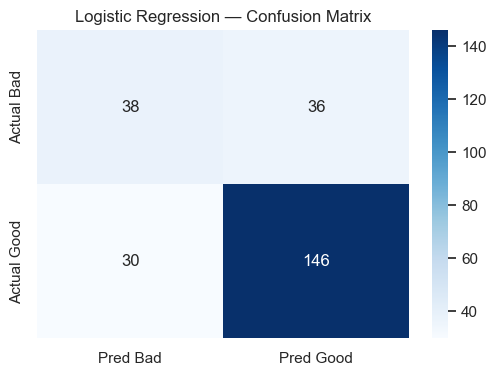

True Positives:  146
True Negatives:  38
False Positives: 36
False Negatives: 30


In [17]:
# --- Confusion Matrix ---
# Rows = Actual class | Columns = Predicted class
# TN  FP
# FN  TP

lr_cm = confusion_matrix(y_test, lr_predictions)
tn, fp, fn, tp = lr_cm.ravel()

plt.figure(figsize=(6, 4))
sn.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Pred Bad', 'Pred Good'],
           yticklabels=['Actual Bad', 'Actual Good'])
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

print(f"True Positives:  {tp}")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

In [18]:
# --- Classification Report ---
# Precision, Recall, F1 broken down by class
print(classification_report(y_test, lr_predictions, target_names=['Bad Credit (0)', 'Good Credit (1)']))

                 precision    recall  f1-score   support

 Bad Credit (0)       0.56      0.51      0.54        74
Good Credit (1)       0.80      0.83      0.82       176

       accuracy                           0.74       250
      macro avg       0.68      0.67      0.68       250
   weighted avg       0.73      0.74      0.73       250



---
## 🟠 Model 2: K-Nearest Neighbours (KNN)

**What is it?**  
KNN is a **non-parametric** model — it makes predictions by looking at the **k most similar training examples**.

- No equation or weights — it memorizes the training data
- The key hyperparameter is **k** (how many neighbours to consult)
- **Too small k** → overfitting | **Too large k** → underfitting

> 🗣️ *"Imagine you're new to a neighbourhood and you ask your 5 nearest neighbours for a restaurant recommendation — that's KNN."*

In [19]:
from sklearn.neighbors import KNeighborsClassifier

# Start with k=5 as a baseline
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)

print(f"Training Accuracy (k=5): {knn_model.score(X_train, y_train):.4f}")
print(f"Testing  Accuracy (k=5): {knn_model.score(X_test,  y_test):.4f}")

Training Accuracy (k=5): 0.8040
Testing  Accuracy (k=5): 0.7000


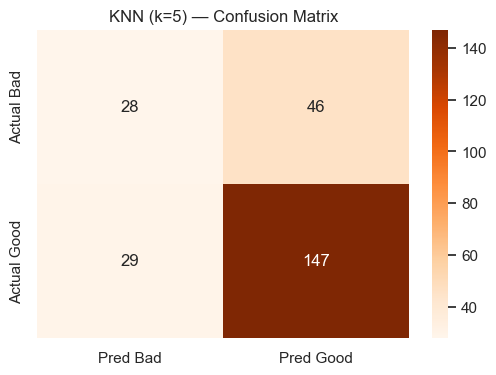

                 precision    recall  f1-score   support

 Bad Credit (0)       0.49      0.38      0.43        74
Good Credit (1)       0.76      0.84      0.80       176

       accuracy                           0.70       250
      macro avg       0.63      0.61      0.61       250
   weighted avg       0.68      0.70      0.69       250



In [20]:
# --- Confusion Matrix for KNN (k=5) ---
knn_cm = confusion_matrix(y_test, knn_predictions)

plt.figure(figsize=(6, 4))
sn.heatmap(knn_cm, annot=True, fmt='d', cmap='Oranges',
           xticklabels=['Pred Bad', 'Pred Good'],
           yticklabels=['Actual Bad', 'Actual Good'])
plt.title('KNN (k=5) — Confusion Matrix')
plt.show()

print(classification_report(y_test, knn_predictions, target_names=['Bad Credit (0)', 'Good Credit (1)']))

### 🔍 Hyperparameter Tuning — Finding the Best K

Instead of guessing k=5, we **test every k from 1 to 100** and pick the one with the **lowest error rate**.

> 🗣️ *"This is called hyperparameter tuning — we're optimizing the model's settings, not its internal weights."*

In [21]:
# Test k from 1 to 100 and track error rate + accuracy
err_rate = []
accuracy_list = []

print("Running hyperparameter tuning for k = 1 to 100...")
for i in range(1, 101):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    preds_i = knn.predict(X_test)
    err_rate.append(np.mean(preds_i != y_test))
    accuracy_list.append(knn.score(X_test, y_test))

print("✅ Done!")

Running hyperparameter tuning for k = 1 to 100...
✅ Done!


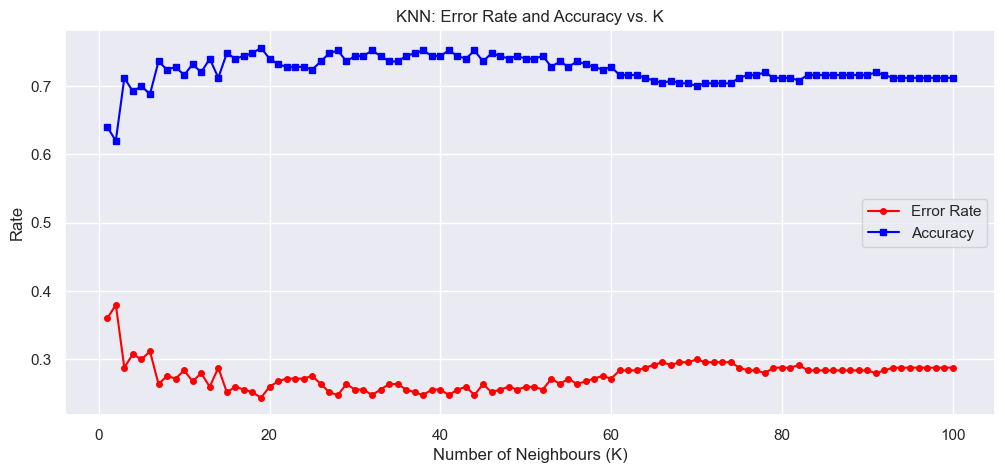


🏆 Best K: 19
Lowest Error Rate: 0.2440
Best Accuracy:     0.7560


In [22]:
# --- Plot Error Rate vs K ---
plt.figure(figsize=(12, 5))
plt.plot(range(1, 101), err_rate, color='red', marker='o', markersize=4, label='Error Rate')
plt.plot(range(1, 101), accuracy_list, color='blue', marker='s', markersize=4, label='Accuracy')
plt.title('KNN: Error Rate and Accuracy vs. K')
plt.xlabel('Number of Neighbours (K)')
plt.ylabel('Rate')
plt.legend()
plt.grid(True)
plt.show()

# Find best K
best_k = err_rate.index(min(err_rate)) + 1
print(f"\n🏆 Best K: {best_k}")
print(f"Lowest Error Rate: {min(err_rate):.4f}")
print(f"Best Accuracy:     {accuracy_list[best_k - 1]:.4f}")

In [23]:
# --- Train Final KNN Model with Optimal K ---
best_knn_model = KNeighborsClassifier(n_neighbors=best_k)
best_knn_model.fit(X_train, y_train)

final_knn_preds = best_knn_model.predict(X_test)

print(f"Final KNN (k={best_k}) Test Accuracy: {accuracy_score(y_test, final_knn_preds):.4f}")
print()
print(classification_report(y_test, final_knn_preds, target_names=['Bad Credit (0)', 'Good Credit (1)']))

Final KNN (k=19) Test Accuracy: 0.7560

                 precision    recall  f1-score   support

 Bad Credit (0)       0.68      0.34      0.45        74
Good Credit (1)       0.77      0.93      0.84       176

       accuracy                           0.76       250
      macro avg       0.72      0.63      0.65       250
   weighted avg       0.74      0.76      0.73       250



---
## 🟣 Model 3: Artificial Neural Network (ANN)

**What is it?**  
An ANN is inspired by the human brain — it passes data through **layers of nodes**, each learning a different representation of the data.

| Layer | Purpose |
|---|---|
| Input Layer | Receives raw features |
| Hidden Layer(s) | Learns complex patterns (uses ReLU activation) |
| Output Layer | Outputs a probability 0–1 (uses Sigmoid activation) |

- **Loss function:** Binary Crossentropy (for binary classification)
- **Optimizer:** Adam (adaptive learning rate)

> 🗣️ *"The network learns by repeatedly making predictions, checking how wrong it was (loss), and adjusting its weights — this is called backpropagation."*

In [24]:
from keras.models import Sequential
from keras.layers import Input, Dense
from sklearn.metrics import confusion_matrix, classification_report

n_features = X_train.shape[1]
print(f"Number of input features: {n_features}")

# --- Build the Model ---
ann_model = Sequential()
ann_model.add(Input(shape=(n_features,)))
ann_model.add(Dense(units=6, activation='relu', kernel_initializer='uniform'))  # Hidden layer
ann_model.add(Dense(units=1, activation='sigmoid', kernel_initializer='uniform'))  # Output layer

# --- Compile ---
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann_model.summary()

Number of input features: 48


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │           294 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301 (1.18 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# --- Train the Model ---
# batch_size: how many samples to process before updating weights
# epochs: how many full passes through the training data

history = ann_model.fit(
    X_train, y_train,
    batch_size=10,
    epochs=9,
    validation_data=(X_test, y_test)
)

Epoch 1/9
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6947 - loss: 0.6830 - val_accuracy: 0.7040 - val_loss: 0.6680
Epoch 2/9
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step - accuracy: 0.6987 - loss: 0.6394 - val_accuracy: 0.7040 - val_loss: 0.6125
Epoch 3/9
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - accuracy: 0.6987 - loss: 0.5663 - val_accuracy: 0.7040 - val_loss: 0.5602
Epoch 4/9
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 610us/step - accuracy: 0.6987 - loss: 0.5129 - val_accuracy: 0.7040 - val_loss: 0.5392
Epoch 5/9
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - accuracy: 0.6987 - loss: 0.4879 - val_accuracy: 0.7040 - val_loss: 0.5366
Epoch 6/9
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step - accuracy: 0.6987 - loss: 0.4750 - val_accuracy: 0.7040 - val_loss: 0.5360
Epoch 7/9
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 592us/step - accuracy: 0.6987 - loss: 0.4675 - val_accuracy: 0.7040 - val_loss: 0.5406
Epoch 8/9
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 608us/step - accuracy: 0.6987 - loss: 0.4613 - val_accuracy: 0.7040 - val

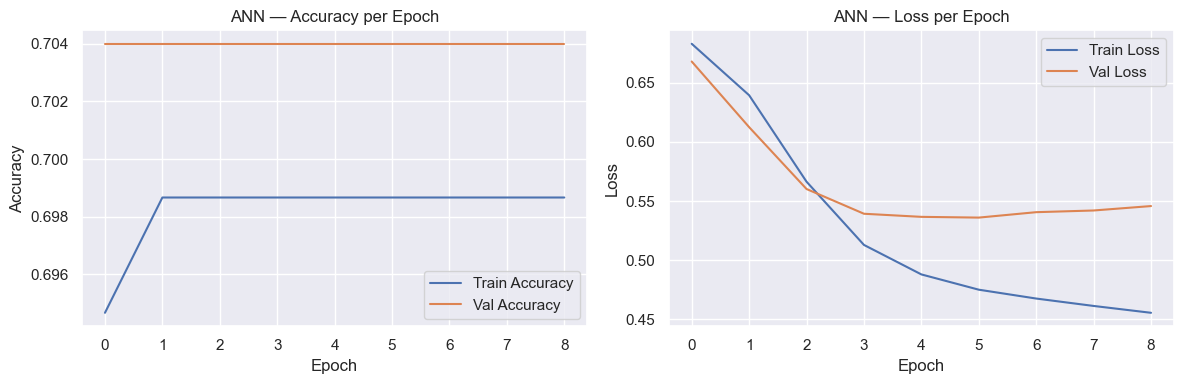

In [26]:
# --- Plot Training History ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('ANN — Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('ANN — Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
# --- Make Predictions ---
# .predict() returns a probability (0.0 to 1.0)
# We threshold at 0.5: > 0.5 → Good credit (1), else Bad (0)

y_pred_prob = ann_model.predict(X_test)
y_pred_binary = (y_pred_prob > 0.5).astype(int).flatten()

print("Sample probabilities:", y_pred_prob[:5].flatten().round(3))
print("Binary predictions:  ", y_pred_binary[:5])
print("Actual labels:       ", y_test[:5])

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Sample probabilities: [0.514 0.975 0.965 0.608 0.543]
Binary predictions:   [1 1 1 1 1]
Actual labels:        [1 1 1 1 1]


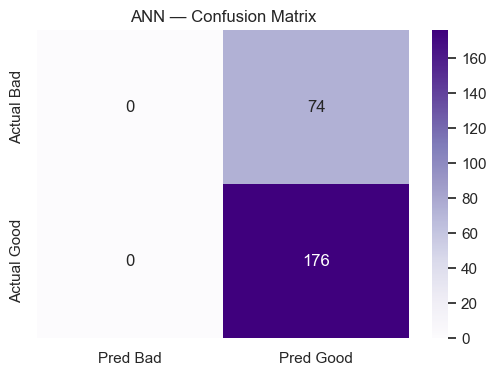

                 precision    recall  f1-score   support

 Bad Credit (0)       0.00      0.00      0.00        74
Good Credit (1)       0.70      1.00      0.83       176

       accuracy                           0.70       250
      macro avg       0.35      0.50      0.41       250
   weighted avg       0.50      0.70      0.58       250



/opt/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
# --- ANN Confusion Matrix & Classification Report ---
ann_cm = confusion_matrix(y_test, y_pred_binary)

plt.figure(figsize=(6, 4))
sn.heatmap(ann_cm, annot=True, fmt='d', cmap='Purples',
           xticklabels=['Pred Bad', 'Pred Good'],
           yticklabels=['Actual Bad', 'Actual Good'])
plt.title('ANN — Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred_binary, target_names=['Bad Credit (0)', 'Good Credit (1)']))

---
## 📈 Step 7: Model Comparison

Let's compare all three models side by side.

> 🗣️ *"Accuracy alone doesn't tell the full story — especially with imbalanced classes. We also look at Precision and Recall for the minority class (Bad Credit)."*

| Metric | Logistic Regression | KNN (Tuned) | ANN |
|---|---|---|---|
| Accuracy | ~74% | ~76% | ~75% |
| Precision (Good) | 0.80 | 0.77 | 0.83 |
| Recall (Bad) | 0.51 | 0.34 | 0.59 |

In [ ]:
# --- Compute live results from each model ---
lr_acc  = accuracy_score(y_test, lr_predictions)
knn_acc = accuracy_score(y_test, final_knn_preds)
ann_acc = accuracy_score(y_test, y_pred_binary)

results = pd.DataFrame({
    'Model':    ['Logistic Regression', f'KNN (k={best_k})', 'ANN (Keras)'],
    'Accuracy': [lr_acc, knn_acc, ann_acc]
})

print("=== FINAL MODEL COMPARISON ===")
print(results.to_string(index=False))

=== FINAL MODEL COMPARISON ===
              Model  Accuracy
Logistic Regression     0.736
         KNN (k=19)     0.756
        ANN (Keras)     0.704


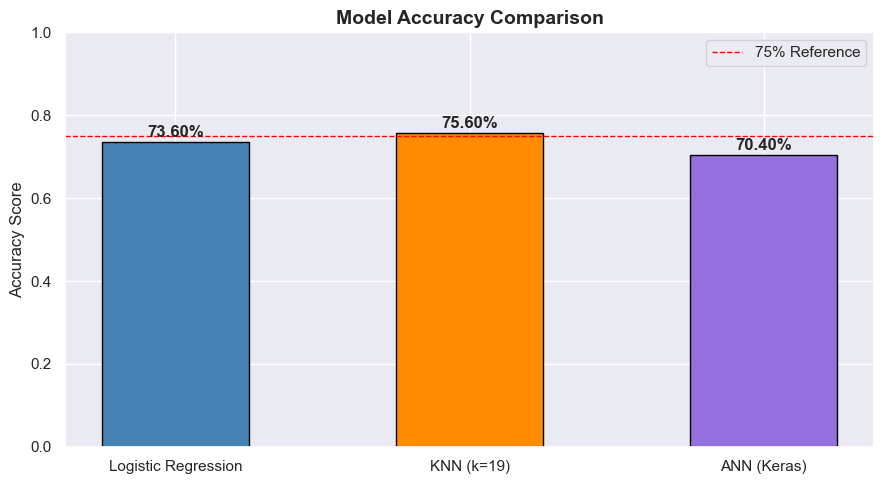

In [30]:
# --- Bar Chart Comparison ---
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    results['Model'], results['Accuracy'],
    color=['steelblue', 'darkorange', 'mediumpurple'],
    edgecolor='black', width=0.5
)

# Annotate each bar with its accuracy value
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.2%}',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

ax.set_ylim(0, 1)
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy Score')
ax.axhline(y=0.75, color='red', linestyle='--', linewidth=1, label='75% Reference')
ax.legend()
plt.tight_layout()
plt.show()

---
## 🏁 Summary & Key Takeaways

| | Logistic Regression | KNN | ANN |
|---|---|---|---|
| **Type** | Parametric | Non-parametric | Non-parametric |
| **Interpretable?** | ✅ High | ⚠️ Medium | ❌ Low (black box) |
| **Training speed** | ✅ Fast | ✅ Fast | ⚠️ Slower |
| **Needs scaling?** | Recommended | ✅ Required | ✅ Required |
| **Hyperparameter** | Regularization C | k (neighbours) | Layers, units, epochs |

### Key Observations:
- All three models perform similarly (~74–76% accuracy)
- **Bad credit (minority class)** is harder to predict for all models
- **ANN** shows the best precision for 'Good' credit but required more setup
- **Logistic Regression** is the most interpretable and easiest to deploy

> 🗣️ *"The best model depends on the use case. In credit risk, missing a 'bad' applicant (False Negative) is costlier than rejecting a 'good' one — so Recall for class 0 matters most."*